# Collecting Data

In [126]:
import pandas as pd
player_df = pd.read_csv("D:\\Python-Assigment\\source code\\results.csv")
transfer_df = pd.read_csv("D:\\Python-Assigment\\source code\\Transfer_values.csv")


#merge 2 df on 
result_df = pd.merge(transfer_df,player_df,how="left", on=["Player","Team"])
result_df.replace("N/a",pd.NA,inplace=True)
# Show all rows
print(result_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Player                     299 non-null    object 
 1   Team                       299 non-null    object 
 2   Played Time                299 non-null    float64
 3   Estimated Value            299 non-null    object 
 4   Nation                     298 non-null    object 
 5   Pos                        298 non-null    object 
 6   Age                        298 non-null    float64
 7   Standard_MP                298 non-null    float64
 8   Standard_Starts            298 non-null    float64
 9   Standard_Min               298 non-null    float64
 10  Standard_Gls               298 non-null    float64
 11  Standard_Ast               298 non-null    float64
 12  Standard_CrdY              298 non-null    float64
 13  Standard_CrdR              298 non-null    float64

In [127]:
result_df.describe()
result_df

,Player,Team,Played Time,Estimated Value,Nation,Pos,Age,Standard_MP,Standard_Starts,Standard_Min,...,Possession_Rec,Possession_PrgR,Misc_Fls,Misc_Fld,Misc_Off,Misc_Crs,Misc_Recov,Misc_Won,Misc_Lost,Misc_Won%
0,Aaron Ramsdale,Southampton,2340.0,€18.7M,ENG,GK,26.96,26.0,26.0,2340.0,...,628.0,0.0,1.0,4.0,0.0,0.0,19.0,5.0,0.0,100.0
1,Aaron Wan-Bissaka,West Ham,2794.0,€29.7M,ENG,DF,27.42,32.0,31.0,2794.0,...,1135.0,139.0,22.0,24.0,4.0,64.0,155.0,22.0,29.0,43.1
2,Abdoulaye Doucouré,Everton,2425.0,€5.8M,MLI,MF,32.33,30.0,29.0,2425.0,...,705.0,91.0,46.0,5.0,10.0,23.0,139.0,29.0,43.0,40.3
3,Adam Armstrong,Southampton,1248.0,€15.1M,ENG,"FW,MF",28.22,20.0,15.0,1248.0,...,286.0,79.0,12.0,5.0,9.0,14.0,23.0,5.0,9.0,35.7
4,Adam Smith,Bournemouth,1409.0,€1.5M,ENG,DF,34.00,22.0,17.0,1409.0,...,333.0,31.0,15.0,11.0,0.0,30.0,43.0,12.0,13.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,Yukinari Sugawara,Southampton,1467.0,€15.8M,JPN,"DF,MF",24.84,29.0,15.0,1467.0,...,692.0,76.0,15.0,9.0,4.0,69.0,40.0,5.0,9.0,35.7
295,Yves Bissouma,Tottenham,1210.0,€30M,MLI,MF,28.67,24.0,15.0,1210.0,...,657.0,3.0,22.0,18.0,0.0,2.0,71.0,4.0,7.0,36.4
296,Álex Moreno,Nott'ham Forest,955.0,€11.2M,ESP,"DF,MF",31.89,15.0,11.0,955.0,...,258.0,34.0,12.0,6.0,0.0,19.0,50.0,3.0,11.0,21.4
297,İlkay Gündoğan,Manchester City,1967.0,€11M,GER,MF,34.52,30.0,22.0,1967.0,...,1330.0,81.0,14.0,21.0,0.0,57.0,104.0,13.0,11.0,54.2


# Preprocessing Data

In [ ]:

# List of columns to convert to numeric
cols_to_convert = ['Shooting_Dist', 'Passing_Long_Cmp%', 'Possession_Succ%', 
                   'Possession_Tkld%', 'Misc_Won%','Shooting_SoT%', 'Shooting_G/Sh']

# Convert only those columns to numeric
result_df[cols_to_convert] = result_df[cols_to_convert].apply(pd.to_numeric, errors='coerce')


# Function to convert currency in '€12.6M' format to a number
def convert_to_numeric(value):
    if isinstance(value, str):
        # Remove the currency symbol and any spaces
        value = value.replace('€', '').strip()
        
        # Check for 'M' (million) and convert accordingly
        if 'M' in value:
            return float(value.replace('M', '').strip()) * 1_000_000
        # Check for 'K' (thousand) and convert accordingly
        elif 'K' in value:
            return float(value.replace('K', '').strip()) * 1_000
        # If there is no 'M' or 'K', assume the number is already in a proper format
        else:
            return float(value)
    return value

# Apply the function to the specific columns
result_df['Estimated Value'] = result_df['Estimated Value'].apply(convert_to_numeric)
#remove outlier
result_df = result_df[result_df["Player"] != "Mohamed Salah"]
result_df = result_df.drop(
    ['Player', 'Team', 'Nation', 'Pos',
     'Goalkeeping_GA90', 'Goalkeeping_Save%',
     'Goalkeeping_CS%', 'Goalkeeping_Penalty_Save%'],
    axis=1,
    errors='ignore'
)

result_df = result_df.fillna(0)
result_df
object_col_count = result_df.select_dtypes(include='object').shape[1]
print(f"Number of object columns: {object_col_count}")
object_columns = result_df.select_dtypes(include='object').columns.tolist()
print("Object columns:", object_columns)
numeric_col_count = result_df.select_dtypes(include='number').shape[1]
print(f"Number of numeric columns: {numeric_col_count}")
numeric_columns = result_df.select_dtypes(include='number').columns.tolist()
print("Numeric columns:", numeric_columns)
result_df


Number of object columns: 0
Object columns: []
Number of numeric columns: 72
Numeric columns: ['Played Time', 'Estimated Value', 'Age', 'Standard_MP', 'Standard_Starts', 'Standard_Min', 'Standard_Gls', 'Standard_Ast', 'Standard_CrdY', 'Standard_CrdR', 'Standard_xG', 'Standard_xAG', 'Standard_PrgC', 'Standard_PrgP', 'Standard_PrgR', 'Standard_Gls/90', 'Standard_Ast/90', 'Standard_xG/90', 'Standard_xAG/90', 'Shooting_SoT%', 'Shooting_SoT/90', 'Shooting_G/Sh', 'Shooting_Dist', 'Passing_Cmp', 'Passing_Total_Cmp%', 'Passing_TotDist', 'Passing_Short_Cmp%', 'Passing_Medium_Cmp%', 'Passing_Long_Cmp%', 'Passing_KP', 'Passing_1/3', 'Passing_PPA', 'Passing_CrsPA', 'Passing_PrgP', 'GCA_SCA', 'GCA_SCA90', 'GCA_GCA', 'GCA_GCA90', 'Defense_Tkl', 'Defense_TklW', 'Defense_Att', 'Defense_Lost', 'Defense_Blocks', 'Defense_Sh', 'Defense_Pass', 'Defense_Int', 'Possession_Touches', 'Possession_Def Pen', 'Possession_Def 3rd', 'Possession_Mid 3rd', 'Possession_Att 3rd', 'Possession_Att Pen', 'Possession_Att',

,Played Time,Estimated Value,Age,Standard_MP,Standard_Starts,Standard_Min,Standard_Gls,Standard_Ast,Standard_CrdY,Standard_CrdR,...,Possession_Rec,Possession_PrgR,Misc_Fls,Misc_Fld,Misc_Off,Misc_Crs,Misc_Recov,Misc_Won,Misc_Lost,Misc_Won%
0,2340.0,18700000.0,26.96,26.0,26.0,2340.0,0.0,0.0,2.0,0.0,...,628.0,0.0,1.0,4.0,0.0,0.0,19.0,5.0,0.0,100.0
1,2794.0,29700000.0,27.42,32.0,31.0,2794.0,2.0,2.0,1.0,0.0,...,1135.0,139.0,22.0,24.0,4.0,64.0,155.0,22.0,29.0,43.1
2,2425.0,5800000.0,32.33,30.0,29.0,2425.0,3.0,1.0,5.0,1.0,...,705.0,91.0,46.0,5.0,10.0,23.0,139.0,29.0,43.0,40.3
3,1248.0,15100000.0,28.22,20.0,15.0,1248.0,2.0,2.0,4.0,0.0,...,286.0,79.0,12.0,5.0,9.0,14.0,23.0,5.0,9.0,35.7
4,1409.0,1500000.0,34.00,22.0,17.0,1409.0,0.0,0.0,6.0,0.0,...,333.0,31.0,15.0,11.0,0.0,30.0,43.0,12.0,13.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,1467.0,15800000.0,24.84,29.0,15.0,1467.0,1.0,1.0,4.0,0.0,...,692.0,76.0,15.0,9.0,4.0,69.0,40.0,5.0,9.0,35.7
295,1210.0,30000000.0,28.67,24.0,15.0,1210.0,2.0,0.0,7.0,0.0,...,657.0,3.0,22.0,18.0,0.0,2.0,71.0,4.0,7.0,36.4
296,955.0,11200000.0,31.89,15.0,11.0,955.0,0.0,1.0,2.0,0.0,...,258.0,34.0,12.0,6.0,0.0,19.0,50.0,3.0,11.0,21.4
297,1967.0,11000000.0,34.52,30.0,22.0,1967.0,0.0,5.0,1.0,0.0,...,1330.0,81.0,14.0,21.0,0.0,57.0,104.0,13.0,11.0,54.2


# Data Visualization



Top features with highest absolute correlation to the target variable (after multicollinearity removal and filtering > 0.3):
Possession_Att Pen --> Correlation: 0.4830
GCA_GCA --> Correlation: 0.4684
Age --> Correlation: 0.4567
Standard_Gls --> Correlation: 0.4338
Possession_1/3 --> Correlation: 0.4215
Passing_PPA --> Correlation: 0.4181
Standard_xAG --> Correlation: 0.4141
GCA_SCA90 --> Correlation: 0.4135
Standard_PrgC --> Correlation: 0.3974
Standard_PrgP --> Correlation: 0.3928
Standard_Ast --> Correlation: 0.3914
Possession_Dis --> Correlation: 0.3860
Standard_PrgR --> Correlation: 0.3777
Possession_CPA --> Correlation: 0.3742
Possession_Att --> Correlation: 0.3639
Possession_Mis --> Correlation: 0.3430
Possession_PrgDist --> Correlation: 0.3345
Misc_Fld --> Correlation: 0.3298


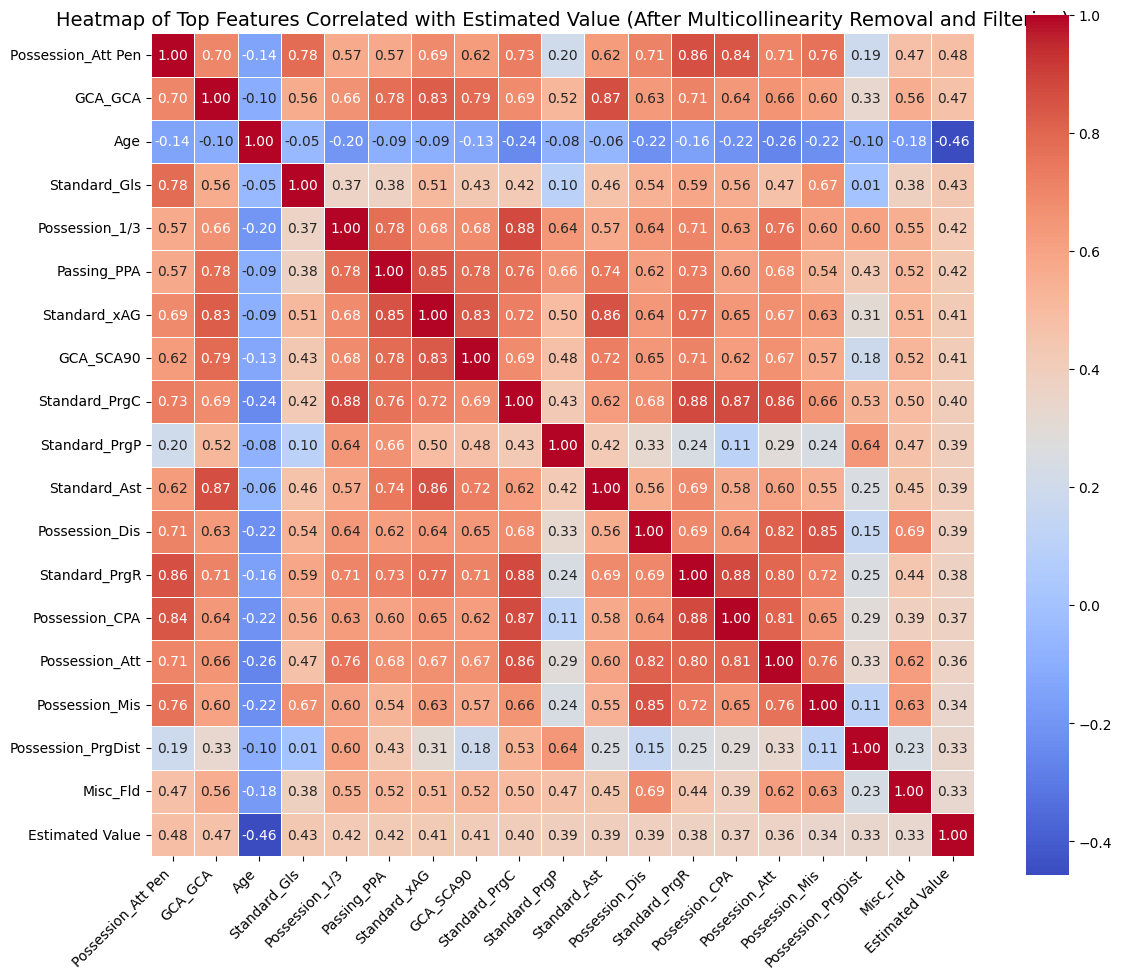

0      18700000.0
1      29700000.0
2       5800000.0
3      15100000.0
4       1500000.0
          ...    
294    15800000.0
295    30000000.0
296    11200000.0
297    11000000.0
298      900000.0
Name: Estimated Value, Length: 298, dtype: float64
Selected features list: ['Possession_Att Pen', 'GCA_GCA', 'Age', 'Standard_Gls', 'Possession_1/3', 'Passing_PPA', 'Standard_xAG', 'GCA_SCA90', 'Standard_PrgC', 'Standard_PrgP', 'Standard_Ast', 'Possession_Dis', 'Standard_PrgR', 'Possession_CPA', 'Possession_Att', 'Possession_Mis', 'Possession_PrgDist', 'Misc_Fld']


In [129]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get the 20 highest absolute correlation in Estimated Value column

X = result_df.drop(columns=['Estimated Value'])  # Dropping the target column to create the feature matrix
y = result_df['Estimated Value']  # Defining the target variable

# Calculate the correlation with the target variable (y)
target_corr = X.corrwith(y).abs().sort_values(ascending=False)

# Remove highly correlated features (multicollinearity check)
corr_matrix = X.corr()  # Correlation matrix of features
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle of the correlation matrix

# Find features with correlation greater than 0.9
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
X_cleaned = X.drop(columns=to_drop)  # Removing highly correlated features

# Recalculate the correlation with the target variable
target_corr_cleaned = X_cleaned.corrwith(y).abs().sort_values(ascending=False)

# Filter features with absolute correlation above 0.3
target_corr_filtered = target_corr_cleaned[target_corr_cleaned > 0.3]

# Print top features most correlated with the target variable (after removing multicollinearity and filtering)
print("\nTop features with highest absolute correlation to the target variable (after multicollinearity removal and filtering > 0.3):")
for feature, corr_val in target_corr_filtered.items():
    print(f"{feature} --> Correlation: {corr_val:.4f}")

# Save the selected feature names to a list
top_features_list = target_corr_filtered.index.tolist()

# Create the final dataset with the selected features and the target variable
top_features = result_df[top_features_list + ['Estimated Value']]

# Compute the correlation matrix for the selected features
corr_matrix_cleaned = top_features.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(corr_matrix_cleaned, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

# Set plot title
plt.title("Heatmap of Top Features Correlated with Estimated Value (After Multicollinearity Removal and Filtering)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the target variable
print(y)

# Now the selected features are saved in top_features_list
print("Selected features list:", top_features_list)


# Model Building


🔹 Training Linear Regression...
Validation R²: 0.3396
Linear Regression - Test MSE: 760255305786955.3750, MAE: 15478748.9916, R²: 0.4479

🔹 Training Ridge Regression...
Validation R²: 0.3402
Ridge Regression - Test MSE: 760486239453336.3750, MAE: 15484885.8968, R²: 0.4477

🔹 Training Lasso Regression...
Validation R²: 0.3396
Lasso Regression - Test MSE: 760255307410519.8750, MAE: 15478749.0538, R²: 0.4479

🔹 Training Random Forest...
Validation R²: 0.4040
Random Forest - Test MSE: 964834315500000.0000, MAE: 17302833.3333, R²: 0.2993

🔹 Training XGBoost...
Validation R²: 0.1112
XGBoost - Test MSE: 1130231564242354.0000, MAE: 18568291.6417, R²: 0.1791


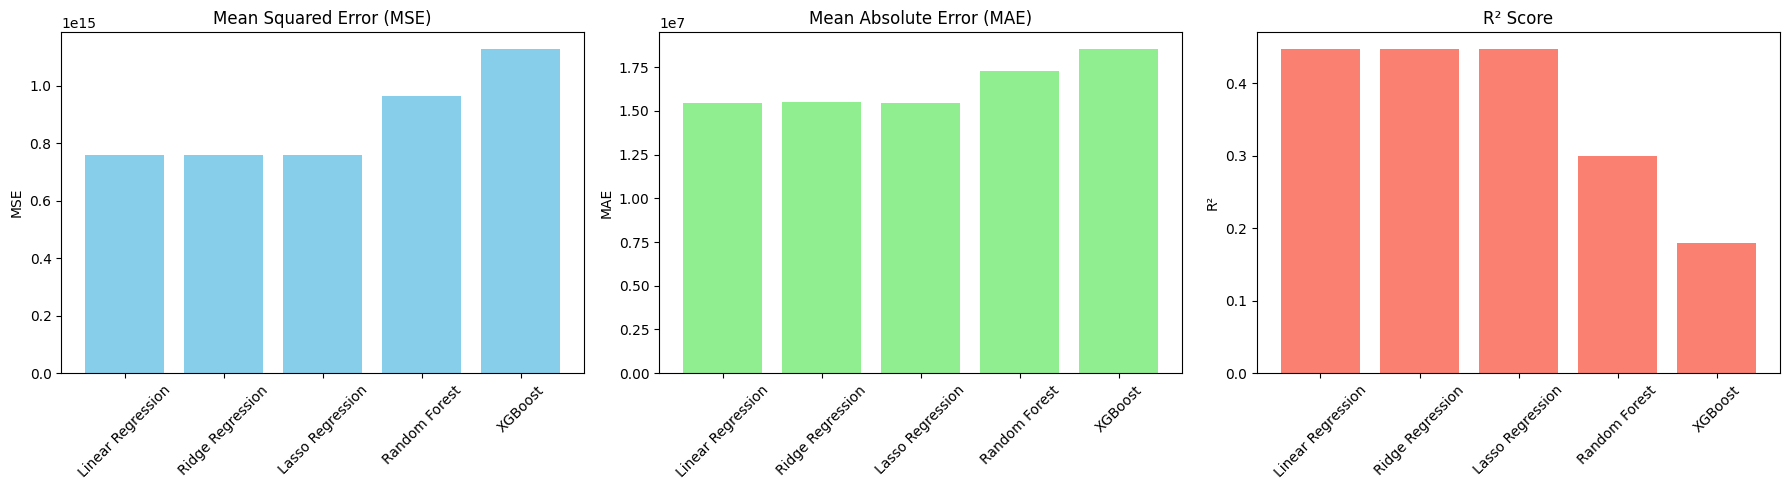

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import matplotlib.pyplot as plt

# === Define X and y ===
X = result_df[top_features_list]
y = result_df['Estimated Value']

# First split: Train (80%) vs Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=20)

# Second split: Temp (20%) into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=20)

# === Define models ===
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(random_state=0),
    "XGBoost": xgb.XGBRegressor(random_state=0, verbosity=0)
}

# === Initialize metrics for plotting ===
metrics = {
    'Model': [],
    'MSE': [],
    'MAE': [],
    'R²': []
}

# === Train, Evaluate, Save models ===
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)  # Train on the correct training data

    # Predict on test set
    y_pred = model.predict(X_test)

    # Predict on validation set
    y_val_pred = model.predict(X_val)

    # Evaluation on test set
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Evaluation on validation set (just print)
    val_r2 = r2_score(y_val, y_val_pred)
    print(f"Validation R²: {val_r2:.4f}")

    # Store metrics for plotting (only test set)
    metrics['Model'].append(name)
    metrics['MSE'].append(mse)
    metrics['MAE'].append(mae)
    metrics['R²'].append(r2)

    # Print the model scores
    print(f"{name} - Test MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# === Plotting comparison of models ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot MSE
axes[0].bar(metrics['Model'], metrics['MSE'], color='skyblue')
axes[0].set_title('Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE
axes[1].bar(metrics['Model'], metrics['MAE'], color='lightgreen')
axes[1].set_title('Mean Absolute Error (MAE)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# Plot R²
axes[2].bar(metrics['Model'], metrics['R²'], color='salmon')
axes[2].set_title('R² Score')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Data split into training, validation, and testing sets.
Linear Regression training completed.

Model Performance:
Training R²: 0.6213
Validation R²: 0.6887
Test R²: 0.6966

Cross-validation MSE on training set: -0.4334581198714246

Training Metrics:
  MSE : 755950587246020.8750
  MAE : 14037643.2570
  R²  : 0.6213

Validation Metrics:
  MSE : 109322006049297.0312
  MAE : 8838548.8101
  R²  : 0.6887

Test Metrics:
  MSE : 295618211676373.8125
  MAE : 11839192.6439
  R²  : 0.6966


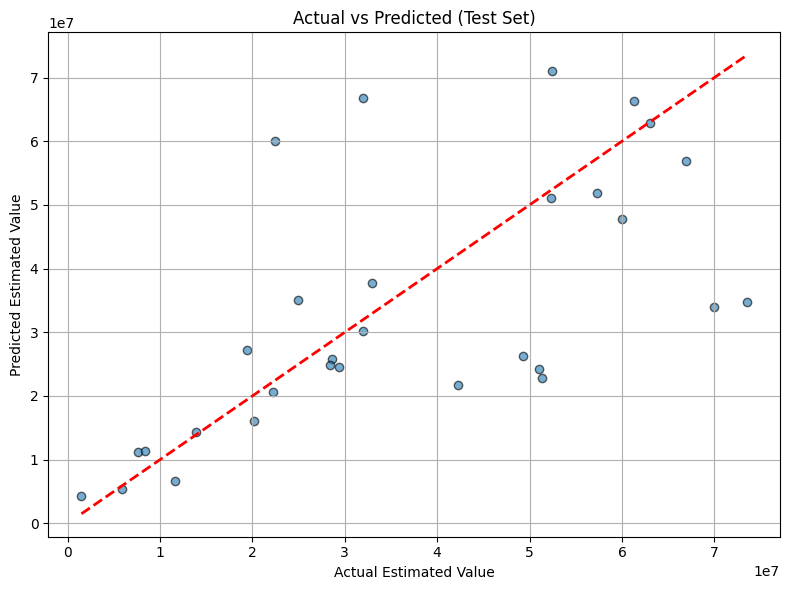

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Step 1: Filter dataset ===
required_columns = top_features_list + ['Estimated Value']
dataset = result_df[required_columns]

# === Step 2: Handle missing values ===
dataset = dataset.dropna(subset=['Estimated Value'])
dataset[top_features_list] = dataset[top_features_list].fillna(dataset[top_features_list].median())

# === Step 3: Define X and y (log-transform y) ===
X = dataset[top_features_list]
y = np.log1p(dataset['Estimated Value'])

# === Step 4: Split data into training, validation, and test sets ===
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=30)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=30)
print("Data split into training, validation, and testing sets.")

# === Step 5: Standardize features ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# === Step 6: Train linear regression model ===
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Linear Regression training completed.")

# === Step 7: Evaluate R² on training, validation, and test sets ===
train_score = model.score(X_train_scaled, y_train)
val_score = model.score(X_val_scaled, y_val)
test_score = model.score(X_test_scaled, y_test)

print("\nModel Performance:")
print(f"Training R²: {train_score:.4f}")
print(f"Validation R²: {val_score:.4f}")
print(f"Test R²: {test_score:.4f}")

# === Step 8: Cross-validation MSE on training set ===
cv_mse = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print("\nCross-validation MSE on training set:", cv_mse.mean())

# === Step 9: Make predictions (log scale) ===
y_train_pred_log = model.predict(X_train_scaled)
y_val_pred_log = model.predict(X_val_scaled)
y_test_pred_log = model.predict(X_test_scaled)

# === Step 10: Convert predictions back to original scale ===
y_train_pred = np.expm1(y_train_pred_log)
y_val_pred = np.expm1(y_val_pred_log)
y_test_pred = np.expm1(y_test_pred_log)
y_train_actual = np.expm1(y_train)
y_val_actual = np.expm1(y_val)
y_test_actual = np.expm1(y_test)

# === Step 11: Define metric reporting function ===
def print_mixed_metrics(y_true_log, y_pred_log, y_true_orig, y_pred_orig, dataset_name):
    mse = mean_squared_error(y_true_orig, y_pred_orig)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_log, y_pred_log)
    print(f"\n{dataset_name} Metrics:")
    print(f"  MSE : {mse:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  R²  : {r2:.4f}")

# === Step 12: Print metrics for all datasets ===
print_mixed_metrics(y_train, y_train_pred_log, y_train_actual, y_train_pred, "Training")
print_mixed_metrics(y_val, y_val_pred_log, y_val_actual, y_val_pred, "Validation")
print_mixed_metrics(y_test, y_test_pred_log, y_test_actual, y_test_pred, "Test")

# === Step 13: Plot Actual vs Predicted (Test Set) ===
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_test_pred, alpha=0.6, edgecolor='k')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Estimated Value')
plt.ylabel('Predicted Estimated Value')
plt.title('Actual vs Predicted (Test Set)')
plt.grid(True)
plt.tight_layout()
plt.show()